**Environment**

In [1]:
# %pip install pandas numpy matplotlib seaborn scipy tabulate
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from IPython.core.getipython import get_ipython

def auto_reload_model():
    if 'model' in sys.modules:
        importlib.reload(sys.modules['model'])

ipython = get_ipython()
if ipython:
    ipython.events.register('pre_execute', auto_reload_model)


from model import *

**Input Data**

In [2]:
# Data path
project_root = Path.cwd()
data_path = project_root / "data"

# Output location
output_location = project_root / "output"
output_location.mkdir(parents=True, exist_ok=True)

# Liabilities
liabilities_df = pd.read_csv(data_path / 'liabs.csv', parse_dates=['date'], dayfirst=True, index_col = 'date')
liabilities = Liabilities(
    dates=liabilities_df.index.to_list(),
    cashflows=liabilities_df['cashflow']
)

# German Goverment Bond (Bund) Yields
bund_yields = pd.read_csv(data_path / 'bund_yields.csv', parse_dates=['date'], index_col = 'date')
rates = Rates(bund_yields['yield'].to_numpy(), bund_yields.index.to_list())

# Spreads
spreads_df = pd.read_csv(data_path / 'credit_spreads.csv', index_col='rating')
spread_map = spreads_df['spread'].to_dict()

# Issuers
issuers_df = pd.read_csv(data_path / 'issuers.csv', dtype={'id': 'str'}, index_col='id')
issuers = Issuers(
    ids=issuers_df.index.to_list(),
    ratings=issuers_df['rating'],
    sectors=issuers_df['sector'],
    names = issuers_df['name']
)

# Bonds
bond_data = pd.read_csv(data_path / 'bonds.csv', dtype={'id': 'str', 'issuer_id': 'str'}, index_col='id')
cashflow_ladder = pd.read_csv(data_path / 'cashflow_ladder.csv', parse_dates=['date'], dayfirst=True).set_index('date')
bonds = Bonds(
    ids = bond_data.index.to_list(),
    issuer_ids = bond_data['issuer_id'],
    recoveries = bond_data['recovery'],
    cashflows = cashflow_ladder,
    issuers = issuers
)

# Transition matrix
tmatrix = pd.read_csv(data_path / 'transition_matrix.csv')
transition_matrix = TransitionMatrix(
    tmatrix = tmatrix.values,
    labels = tmatrix.columns.to_list()
)

# Economy and Sector correlations
rho_e = .24
rho_s = np.array([rho_e])

# Model object
cr_model = CreditRiskModel(
    transition_matrix = transition_matrix,
    rho_e = rho_e,
    rho_s = rho_s,
    issuer_ids = issuers.ids,
    sector_map = issuers.sectors,
    ratings_map = issuers.ratings
)

# Valuation Date
val_date = pd.to_datetime('01-01-2026', dayfirst = True)

# Bond Allocations (Notionals per Bond ID)
cdi_allocation = pd.read_csv(data_path / 'cdi_allocation.csv', index_col = 'id').iloc[:, 0]
cmbp_allocation = pd.read_csv(data_path / 'cmbp_allocation.csv', index_col = 'id').iloc[:, 0]

# Starting Cash Value
cash = 2e06
cdi_t0 = (cdi_allocation * bonds.pv(val_date, rates, spread_map)).sum()

# Mandate Parameters
config = FoxConfig(
    val_date = val_date,
    heubeck_liabilities= 297_033_196,
    r_gaap = 0.0201,
    r_ifrs = 0.039,
    mortality_buffer = 1.0559,
    cmbp_margin = 0.001,
    fee = 0.003,
    asset_buffer = 12.5e06,
    performance_cap = 50e06,
    cash = cash,
    cdi_t0 = cdi_t0
)

# CDI Object
cdi_fox = CDIMandate_Fox(
    liabilities=liabilities,
    cash=cash,
    bonds=bonds,
    cdi_allocation=cdi_allocation,
    cmbp_allocation=cmbp_allocation,
    config=config
)

**ICAAP**

Processing inner scenarios 0 to 10 of 100
Processing inner scenarios 10 to 20 of 100
Processing inner scenarios 20 to 30 of 100
Processing inner scenarios 30 to 40 of 100
Processing inner scenarios 40 to 50 of 100
Processing inner scenarios 50 to 60 of 100
Processing inner scenarios 60 to 70 of 100
Processing inner scenarios 70 to 80 of 100
Processing inner scenarios 80 to 90 of 100
Processing inner scenarios 90 to 100 of 100
|            |      mean |     0.005 |      0.05 |      0.25 |       0.5 |      0.75 |      0.95 |     0.995 |
|:-----------|----------:|----------:|----------:|----------:|----------:|----------:|----------:|----------:|
| pv_hgb_t1  |         0 |         0 |         0 |         0 |         0 |         0 |         0 |         0 |
| pv_perf_t1 | 5,773,229 | 5,257,112 | 5,389,388 | 5,524,714 | 5,657,939 | 5,854,123 | 6,597,485 | 8,006,170 |
| pv_fee_t1  | 8,872,950 | 8,706,137 | 8,807,743 | 8,867,485 | 8,883,436 | 8,892,734 | 8,903,080 | 8,912,108 |


<Axes: ylabel='Count'>

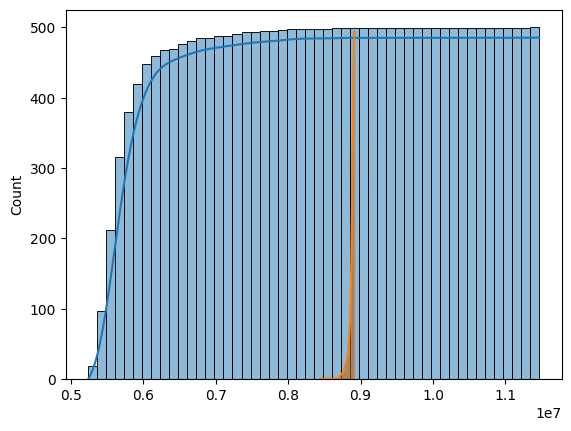

In [3]:
np.random.seed(123)
n_outer = 500
n_inner = 100
n_years = 25
chunk_size = 10

icaap = cdi_fox.run_icaap(val_date, rates, spread_map, cr_model, n_outer, n_inner, n_years, chunk_size)

print(icaap.summary().to_markdown(floatfmt=",.0f"))
sns.histplot(icaap.pv_perf_t1, bins=50, kde=True, cumulative=True)
sns.histplot(icaap.pv_fee_t1, bins=50, kde=True, cumulative=True)